# **Baseline Model Post-Preprocessing**

## To check if the features and encoding helped with our baseline or did harm

**Import packages and data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score)
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv("final_merged_cleaned_preprocessed.csv")
df.head()

,patientunitstayid,age,admissionheight,admissionweight,bmi,dialysis,wbc,respiratoryrate,sodium,heartrate,...,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,region_Northeast,region_South,region_Unknown,region_West,bad_outcome
0,141764,87.0,157.5,79.3,27.298480,0.0,9.9,27.0,138.0,104.0,...,0,0,1,0,0,0,0,0,0,1
1,141765,87.0,157.5,46.5,18.745276,0.0,10.2,39.0,139.0,88.0,...,0,0,1,0,0,0,0,0,0,0
2,143870,76.0,167.0,77.5,27.788734,0.0,11.7,60.0,133.0,40.0,...,0,0,0,0,1,0,0,0,0,0
3,144815,34.0,172.7,60.3,20.217741,0.0,7.9,6.0,141.0,131.0,...,0,0,1,0,0,0,0,0,0,0
4,145427,61.0,177.8,91.7,29.007201,0.0,21.1,41.0,141.0,49.0,...,0,0,0,0,1,0,0,0,0,0


In [5]:
df.shape

(2520, 87)

**Run logistic regression baseline model**

1. **Binary features**
- vitals_missing, io_missing, pred_missing, apache_missing, aps_missing, bad_outcome, dialysis, hx_cardio, hx_respiratory, hx_neuro, hx_cancer, hx_renal, hx_liver, hx_endocrine, hx_immuno, hx_heme, hx_none, drug_allergy, non_drug_allergy, immunosuppression, midur, diabetes, cirrhosis, leukemia, metastaticcancer, hepaticfailure, lymphoma, teachingstatus
2. **ID features**
- patientunitstayid
3. **Categorical features**
- gender: female, male, nan
- ethnicity: caucasian, hispanic, asian, african american, nan, native american, other/unknown
- unittype: med-surg icu, sicu, micu, cticu, neuro icu, ccu-cticu, cardiac icu, cscicu
- numbedscategory: <100, 100-249, nan, >=500, 250-499
- region: midwest, nan, south, west, northeast

In [9]:
X = df.drop(columns=["bad_outcome", "patientunitstayid"])
y = df["bad_outcome"]

# Train-test split 80/20 - no validation just yet
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale data since this is logistic regression
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Build model
model = LogisticRegression(max_iter=3000) # 3k iterations was the best last time

# Fit model
model.fit(X_train, y_train)

# Output predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Output evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       388
           1       0.71      0.47      0.57       116

    accuracy                           0.84       504
   macro avg       0.79      0.71      0.73       504
weighted avg       0.82      0.84      0.82       504

ROC-AUC: 0.827630643441166
PR-AUC: 0.670211356415527


/Users/darleneeligado/anaconda3/envs/capstone_clean/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


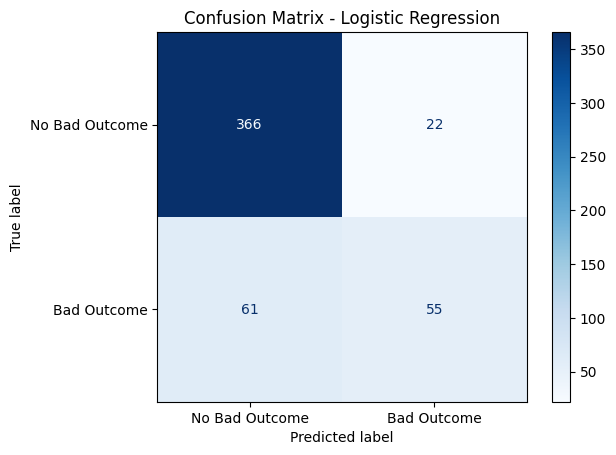

In [11]:
# Output a confusion matrix to see performance
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No Bad Outcome", "Bad Outcome"],
    cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

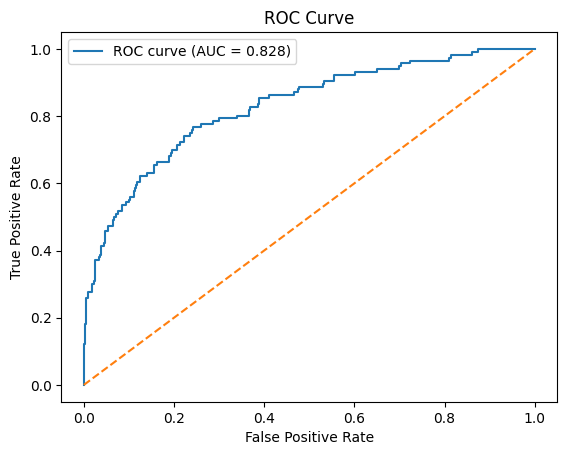

In [13]:
# ROC-curve
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

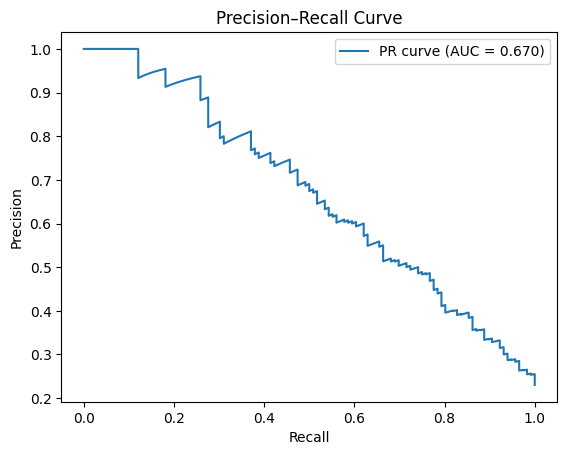

In [15]:
# PR-AUC curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

| Class | Precision | Recall | F1-score | Support |
| ----- | --------- | ------ | -------- | ------- |
| 0     | 0.86      | 0.94   | 0.90     | 388     |
| 1     | 0.70      | 0.47   | 0.56     | 116     |


| Metric          | Value |
| --------------- | ----- |
| Accuracy        | 0.83  |
| Macro Avg F1    | 0.73  |
| Weighted Avg F1 | 0.82  |
| ROC-AUC         | 0.827 |
| PR-AUC          | 0.666 |


From comparison with the rough baseline with 2520 rows and 77 columns, this models performance drops the tiniest bit, with class 1 and ROC-AUC, and PR-AUC. This dataset has 2520 rows and 87 columns. +10 features were added from label-encoding.

**Run logistic regression baseline model with scaling continuous features**

In [21]:
df.columns

Index(['patientunitstayid', 'age', 'admissionheight', 'admissionweight', 'bmi',
       'dialysis', 'wbc', 'respiratoryrate', 'sodium', 'heartrate', 'meanbp',
       'ph', 'hematocrit', 'creatinine', 'albumin', 'pao2', 'pco2', 'bun',
       'glucose', 'bilirubin', 'fio2', 'aps_missing', 'acutephysiologyscore',
       'apachescore', 'apache_missing', 'hepaticfailure', 'lymphoma',
       'metastaticcancer', 'leukemia', 'immunosuppression', 'cirrhosis',
       'diabetes', 'midur', 'pred_missing', 'primary_ratio', 'major_ratio',
       'hx_cardio', 'hx_respiratory', 'hx_neuro', 'hx_cancer', 'hx_renal',
       'hx_liver', 'hx_endocrine', 'hx_immuno', 'hx_heme', 'hx_none',
       'intaketotal', 'outputtotal', 'dialysistotal', 'nettotal', 'io_missing',
       'drug_allergy', 'non_drug_allergy', 'temp_min', 'hr_min', 'hr_max',
       'resp_max', 'sao2_min', 'sbp_min', 'dbp_min', 'map_min',
       'vitals_missing', 'hr_range', 'temp_range', 'numbedscategory',
       'teachingstatus', 'numbed_mis

In [23]:
binary_cols = [
    "vitals_missing","io_missing","pred_missing","apache_missing","aps_missing",
    "dialysis","hx_cardio","hx_respiratory","hx_neuro","hx_cancer","hx_renal",
    "hx_liver","hx_endocrine","hx_immuno","hx_heme","hx_none",
    "drug_allergy","non_drug_allergy","immunosuppression","midur",
    "diabetes","cirrhosis","leukemia","metastaticcancer","hepaticfailure",
    "lymphoma","teachingstatus"]

cat_cols = [col for col in df.columns if any(prefix in col for prefix in [
    "gender_", "ethnicity_", "unittype_", "numbedscategory_", "region_"])]

exclude = binary_cols + cat_cols + ["bad_outcome", "patientunitstayid"]
num_cols = [col for col in df.columns if col not in exclude]

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("bin", "passthrough", binary_cols),
        ("cat", "passthrough", cat_cols),
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000)) # 3k worked last time, no class balancing just yet
]) # exclude class_weight="balanced"

X = df.drop(columns=["bad_outcome", "patientunitstayid"])
y = df["bad_outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       388
           1       0.73      0.46      0.56       116

    accuracy                           0.84       504
   macro avg       0.79      0.70      0.73       504
weighted avg       0.82      0.84      0.82       504

ROC-AUC: 0.8196542836829007
PR-AUC: 0.674187083971491


We will use this for our new baseline to compare our models.